# JN6b · Did we get it right? Scoring our APR against the city's

We've done the whole build: ingested permits, keyed places, counted units, dated completions, sorted out the date concepts. We even have our own Annual Progress Report (JN6a). But there's one question left, and it's the only one that really matters: **is it right?**

The honest way to answer is to put our numbers next to a source we didn't build — the city's own report — and account for *every single unit of difference*. Not "we're close," but "here is exactly where we differ, and here is the name of each gap." This notebook does that: **join** our completions to the city's, **decompose** the difference into named categories, and read the scorecard.

The payoff is the best kind: our own comparison will **rediscover** a limitation we planted by hand back in JN3 — and we'll get to make the grown-up call of whether to fix it or flag it.

**Curriculum notebook 6b of 6.** Clonable + **read-only** — it reads the data and the oracle, never writes.

### Running the cells

To run a cell, click it and press **Shift + Return**, or click the **run (▸) button** on the cell. The simplest way through any notebook here is to start at the top and run each cell in order, reading the output that appears beneath it.

Some of the computational cells may look complex right now — that's expected, and it's fine. **You don't need to understand every line yet;** the ideas become clear as you go. Run them, watch what they produce, and keep moving.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN6a · Interrogate the oracle + generate your APR](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6a_apr_oracle.ipynb)  |  [🎉 You've finished the series — back to the course](https://berkeleybuild.com/data-science-curriculum.html)

## (run first) Colab setup

Fetches the data + shared modules from R2. **No-op if you already have the repo locally** (it detects a checkout and skips). On Colab / a bare session it recreates the minimal repo layout under the working directory so the config cell below finds everything unchanged.

In [1]:
# === COLAB BOOTSTRAP - fetch curriculum data + modules from R2 (NO-OP if the repo is local) ===
from pathlib import Path
import sys, urllib.request, urllib.parse, tarfile, subprocess

R2 = 'https://pub-2cee87f70da64080ab70ee0a34b55099.r2.dev/curriculum'
USE_CLEAN = False   # False: raw .xlsx path (JN1's messy-data lesson).  True (skip-ingest): permits_clean.*

_here = Path.cwd()
_have_repo = (_here/'scripts'/'build_v2').exists() or any((p/'scripts'/'build_v2').exists() for p in _here.parents)

def _get(url):
    # r2.dev sits behind Cloudflare, which 403s the default 'Python-urllib' User-Agent; send a browser UA.
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.read()

if _have_repo:
    print('local repo detected - no fetch needed')
else:
    try:
        import pyarrow  # the parquet / USE_CLEAN path needs it; Colab has pandas, maybe not pyarrow
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'], check=True)
    def _fetch(url, dest):
        dest = Path(dest)
        if dest.exists():
            return                                   # cached: re-runs don't re-download
        dest.parent.mkdir(parents=True, exist_ok=True)
        dest.write_bytes(_get(url)); print('fetched', dest.name)
    # 1) shared modules -> ./scripts/...  (the config-cell repo-root walk then finds scripts/build_v2)
    if not (_here/'scripts'/'build_v2').exists():
        Path('modules.tgz').write_bytes(_get(f'{R2}/curriculum_modules.tar.gz'))
        _tar = tarfile.open('modules.tgz')
        try: _tar.extractall(_here, filter='data')      # py3.12+: safe extract, no deprecation warning
        except TypeError: _tar.extractall(_here)         # older python has no filter arg
        _tar.close(); Path('modules.tgz').unlink(missing_ok=True)   # tidy: drop the intermediate tarball
        print('extracted modules -> ./scripts/')
    # 2) data -> the SAME relative paths the notebooks use (raw .xlsx AND clean exports, both fetched)
    for rel in ['data/raw/cpra-downloads/BP_Annual Permit Report-2018-2022.xlsx',
                'data/raw/cpra-downloads/BP_Annual Permit Report-2023-2025.xlsx',
                'databases/hcd_apr_mirror_2026-06-17_fresh.db',
                'databases/hcd_apr_mirror.db',
                'data/processed/permits_clean.csv',
                'data/processed/permits_clean.parquet',
                'data/processed/permits_clean_README.md']:
        _fetch(f"{R2}/data/{urllib.parse.quote(rel.split('/')[-1])}", _here/rel)   # quote -> %20 for the spaced .xlsx names
    print('curriculum bundle ready (fetched from R2)')


local repo detected - no fetch needed


In [2]:
def md(t):
    from IPython.display import Markdown, display
    display(Markdown(t))

## Config

In [3]:
# === CONFIG (clonable) ===
from pathlib import Path
import sys, glob
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'scripts' / 'build_v2').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PERMIT_GLOB = str(REPO_ROOT / 'data/raw/cpra-downloads/BP_Annual Permit Report-*.xlsx')
ORACLE_DB   = str(REPO_ROOT / 'databases/hcd_apr_mirror_2026-06-17_fresh.db')
HEADER_ROW  = 7
sys.path.insert(0, str(REPO_ROOT / 'scripts')); sys.path.insert(0, str(REPO_ROOT / 'scripts' / 'build_v2'))
print('repo root:', REPO_ROOT)


repo root: /Users/johngage/berkeley-data


## First, get both sides on the table

Before we can compare two reports, we need both of them in hand, in the same shape. On *our* side that means rebuilding our completed buildings from the permit feed — the exact pipeline from JN1–JN5, run in one cell. On the *city's* side it means reading their Annual Progress Report from the oracle database and indexing it two ways: by **address-bucket** (so we can match on place) and by **canonical APN** (so we can match on parcel when the address fails us).

**Our plan:** reconstruct our own completions with the shared pipeline functions, then load and index the city's certificate-of-occupancy rows — so the next step has both sides ready to join.

In [4]:
import pandas as pd, sqlite3
from collections import defaultdict
from housing_predicates import is_housing, net_units
from s0_keys import normalize_address
from cpra_dedup import extract_master_permit
import housing_rules as hr
def pdate(x):
    d = pd.to_datetime(str(x), errors='coerce'); return d.date() if pd.notna(d) else None
def capn(a):
    try: return hr.to_canonical_apn(a, 'Alameda')
    except: return None
def load(p):
    d = pd.read_excel(p, dtype=str, header=HEADER_ROW); d.columns = [str(c).strip() for c in d.columns]; return d
df = pd.concat([load(f) for f in glob.glob(PERMIT_GLOB)], ignore_index=True)
df = df[df['PermitNumber'].notna()].rename(columns={'Finaled Date':'FinaledDate','Parcel Number':'ParcelNumber'}).copy()
df['isnew'] = df['Work Type'].astype(str).str.strip() == 'New'
df = df[[is_housing(o,u,n,a) for o,u,n,a in zip(df['OccType'],df['UnitsAdded'],df['NumberUnits'],df['ADU'])]]
bld = defaultdict(lambda: {'units': 0.0, 'hasnew': False, 'final': [], 'apns': set()})
for r in df.itertuples(index=False):
    st = r.StreetType; st = '' if (st is None or str(st).strip().lower() == 'nan') else str(st)
    k = normalize_address(f'{r.StreetNumber} {r.StreetName} {st}'.strip())
    if not k.number: continue
    b = bld[(k.number, k.street, k.stype)]
    b['units'] = max(b['units'], net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU))
    if r.isnew: b['hasnew'] = True
    ca = capn(str(r.ParcelNumber));  b['apns'].add(ca) if ca else None
    pn = str(r.PermitNumber)
    if extract_master_permit(pn) == pn and net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU) > 0:
        f = pdate(r.FinaledDate)
        if f: b['final'].append(f)
mine = {k: b for k, b in bld.items() if (b['hasnew'] or b['units'] > 0) and b['final']}   # MY completions

# the oracle's CO rows (fresh, deduped), indexed by address-bucket and by canonical APN
CO = ['CO_ACUTELY_LOW_INCOME_DR','CO_ACUTELY_LOW_INCOME_NDR','CO_EXTREMELY_LOW_INCOME_DR','CO_EXTREMELY_INCOME_NDR',
      'CO_VLOW_INCOME_DR','CO_VLOW_INCOME_NDR','CO_LOW_INCOME_DR','CO_LOW_INCOME_NDR','CO_MOD_INCOME_DR','CO_MOD_INCOME_NDR','CO_ABOVE_MOD_INCOME']
S = '+'.join(f"CAST(NULLIF({c},'') AS INT)" for c in CO)
con = sqlite3.connect(f'file:{ORACLE_DB}?mode=ro', uri=True)
obucket, oapn, ofull, seen = defaultdict(list), defaultdict(list), set(), set()
for apn, addr, co, u in con.execute(f"SELECT APN,STREET_ADDRESS,CO_ISSUE_DT1,({S}) u FROM table_a2 WHERE CO_ISSUE_DT1<>''"):
    if (apn, addr, co, u) in seen: continue
    seen.add((apn, addr, co, u)); y = int(co[:4]) if co[:4].isdigit() else None
    if not y: continue
    ak = normalize_address(addr)
    obucket[ak.bucket].append((ak, y, u or 0)); ofull.add((ak.number, ak.street, ak.stype))
    ca = capn(apn)
    if ca: oapn[ca].append((y, u or 0))
print(f'{len(mine)} of my completions vs the oracle CO rows')


951 of my completions vs the oracle CO rows


# PHASE 6c · Join & compare

How do we line up *our* completed buildings against the *city's* rows? The obvious answer — match the address strings — is also the wrong one, and it's the exact trap from JN2: a naive string-`==` join fails on a suffix mismatch (`<2650 TELEGRAPH>` vs `<...AVE>`), so it **under-matches** and makes real matches look like gaps. A building that's in *both* reports gets miscounted as a discrepancy.

The fix we built earlier earns its keep here. We match on the **`matches()` relation** (suffix-tolerant, JN2), and then **augment with the canonical APN** for the handful the address still misses.

**Our plan:** run the join three ways at once — count what a naive `==` would have caught, then how many more the relation recovers, then how many more the APN recovers — so we can *see* the cost of using `==` alone.

In [5]:
string_only = matches_recovered = apn_recovered = unmatched = 0
for k, b in mine.items():
    vk = normalize_address(f'{k[0]} {k[1]} {k[2] or ""}'.strip())
    bucket_cands = [o for o in obucket.get(vk.bucket, []) if vk.matches(o[0])]
    string_hit = (vk.number, vk.street, vk.stype) in ofull         # would a naive == have matched?
    apn_hit = any(a in oapn for a in b['apns'])
    if bucket_cands and string_hit: string_only += 1
    elif bucket_cands:              matches_recovered += 1          # matches() caught a suffix mismatch
    elif apn_hit:                   apn_recovered += 1              # APN caught what the address missed
    else:                           unmatched += 1
matched_core = string_only + matches_recovered + apn_recovered
print(f'naive string== would match : {string_only}')
print(f'  + matches() recovered     : {matches_recovered}   (suffix mismatches a == join drops)')
print(f'  + APN-augment recovered   : {apn_recovered}')
print(f'  = matched core            : {matched_core}    (unmatched: {unmatched})')

naive string== would match : 370
  + matches() recovered     : 320   (suffix mismatches a == join drops)
  + APN-augment recovered   : 11
  = matched core            : 701    (unmatched: 250)


In [6]:
md(f'''## What just happened

We joined our completed buildings to the city's rows, and counted how each layer earned its place. A naive string `==` would have matched only **{string_only}** buildings. The **`matches()` relation** from JN2 recovered **{matches_recovered}** more — real buildings that a `==` would have dropped over nothing but a street-suffix mismatch — and the **canonical APN** caught a further **{apn_recovered}** the address still missed. That's **{matches_recovered + apn_recovered}** matches a naive join would have miscounted as gaps, for a **matched core of {matched_core}** (with **{unmatched}** still unmatched).

The lesson the trap teaches: a join is a *claim that two rows are the same thing*, and `==` makes that claim on spelling. The relation makes it on meaning — and the gap between the two is **{matches_recovered + apn_recovered}** buildings you'd otherwise have chased as phantom discrepancies.''')

## What just happened

We joined our completed buildings to the city's rows, and counted how each layer earned its place. A naive string `==` would have matched only **370** buildings. The **`matches()` relation** from JN2 recovered **320** more — real buildings that a `==` would have dropped over nothing but a street-suffix mismatch — and the **canonical APN** caught a further **11** the address still missed. That's **331** matches a naive join would have miscounted as gaps, for a **matched core of 701** (with **250** still unmatched).

The lesson the trap teaches: a join is a *claim that two rows are the same thing*, and `==` makes that claim on spelling. The relation makes it on meaning — and the gap between the two is **331** buildings you'd otherwise have chased as phantom discrepancies.

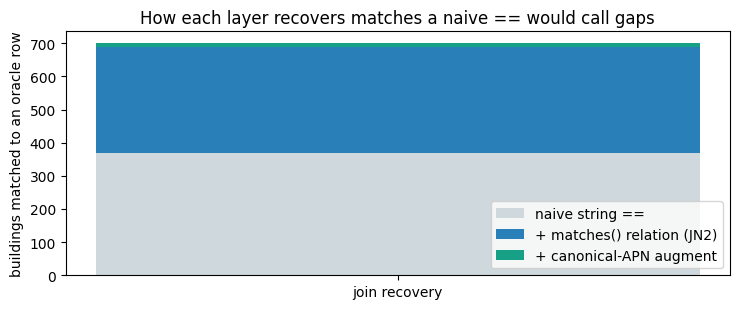

In [7]:
import matplotlib.pyplot as plt
# stack the recovery: what == alone catches, then what the relation adds, then what APN adds
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar('join recovery', string_only,       color='#cfd8dc', label='naive string == ')
ax.bar('join recovery', matches_recovered, bottom=string_only, color='#2980b9',
       label='+ matches() relation (JN2)')
ax.bar('join recovery', apn_recovered, bottom=string_only + matches_recovered, color='#16a085',
       label='+ canonical-APN augment')
ax.set_ylabel('buildings matched to an oracle row')
ax.set_title('How each layer recovers matches a naive == would call gaps')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

### Checkpoint 6c

In [8]:
assert string_only == 370 and matches_recovered == 320 and apn_recovered == 11
assert matched_core == 701
print('CHECKPOINT 6c PASS')
print(f'  matched core {matched_core}; the relation+APN recovered {matches_recovered + apn_recovered} matches a naive == would have called gaps')

CHECKPOINT 6c PASS
  matched core 701; the relation+APN recovered 331 matches a naive == would have called gaps


# PHASE 6d · Decompose & score

So our total and the city's total differ — but by itself a single difference number is almost worthless. "We're off by a few hundred units" could be sloppiness, or it could be a real finding. The only honest scorecard accounts for **every unit** of the difference and gives each one a *name*.

We split the difference, by year and address, into three named buckets:

- **v3-found** — units we have that the city's report lacks at that address (real completions we found);
- **city-coverage** — units the city has that we lack (a genuine coverage gap on our side);
- **matched-diff** — on addresses *both* sides have, the net unit difference.

**Our plan:** bucket every unit of difference into exactly one of these three, then confirm they sum back to (our total − the city's total) — if the decomposition reconciles, nothing is unaccounted for.

In [9]:
mine_by = defaultdict(int); city_by = defaultdict(int)
for k, b in mine.items(): mine_by[(k[:2], max(b['final']).year)] += int(b['units'])
for bk, rows in obucket.items():
    for ak, y, u in rows: city_by[(bk, y)] += u
found = coverage = matched_diff = 0
for key in set(mine_by) | set(city_by):
    v, c = mine_by.get(key, 0), city_by.get(key, 0)
    if v and c: matched_diff += v - c
    elif v:     found += v
    elif c:     coverage += c
net = found - coverage + matched_diff
print(f'  v3-found (city lacks)   : +{found}')
print(f'  city-coverage (I lack)  : -{coverage}')
print(f'  matched-diff            : {matched_diff:+}')
print(f'  ----------------------------------')
print(f'  NET (my total - city)   : {net:+}')

  v3-found (city lacks)   : +573
  city-coverage (I lack)  : -350
  matched-diff            : +78
  ----------------------------------
  NET (my total - city)   : +301


In [10]:
md(f'''## What just happened

We accounted for every unit of the difference between our APR and the city's, and gave each a name. **+{found}** units are *v3-found* — completions we have that the city's report lacks at that address. **−{coverage}** are *city-coverage* — units the city counts that we don't. And on the addresses both sides share, the *matched-diff* nets to **{matched_diff:+}**. Add them up: **{found} − {coverage} {matched_diff:+} = {net:+}** — and that is exactly (our total of **{sum(mine_by.values())}** units) minus the city's deduped total. Nothing is left over.

That reconciliation is the whole point. A difference that decomposes cleanly into named buckets isn't an error to be embarrassed about — it's a *finding*. The next cell drills into the residual and one of these buckets turns out to be a discrepancy we planted ourselves.''')

## What just happened

We accounted for every unit of the difference between our APR and the city's, and gave each a name. **+573** units are *v3-found* — completions we have that the city's report lacks at that address. **−350** are *city-coverage* — units the city counts that we don't. And on the addresses both sides share, the *matched-diff* nets to **+78**. Add them up: **573 − 350 +78 = +301** — and that is exactly (our total of **4310** units) minus the city's deduped total. Nothing is left over.

That reconciliation is the whole point. A difference that decomposes cleanly into named buckets isn't an error to be embarrassed about — it's a *finding*. The next cell drills into the residual and one of these buckets turns out to be a discrepancy we planted ourselves.

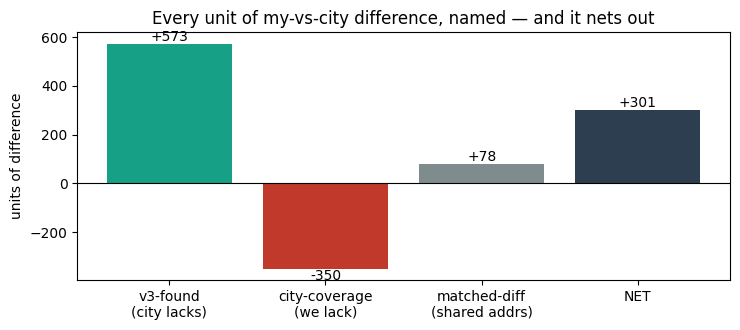

In [11]:
import matplotlib.pyplot as plt
# every unit of difference, signed, in its named bucket -> the three add up to the net
labels = ['v3-found\n(city lacks)', 'city-coverage\n(we lack)', 'matched-diff\n(shared addrs)', 'NET']
vals   = [found, -coverage, matched_diff, net]
colors = ['#16a085', '#c0392b', '#7f8c8d', '#2c3e50']
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(labels, vals, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+}', (b.get_x() + b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
ax.set_ylabel('units of difference')
ax.set_title('Every unit of my-vs-city difference, named — and it nets out')
plt.tight_layout(); plt.show()

## The capstone rediscovery: what's hiding in the residual?

A clean decomposition is reassuring, but the real test of a scorecard is whether it can *find something we didn't already know*. So let's drill into the difference and ask: is there a single address where our APR and the city's report flatly disagree about how many buildings exist?

One address jumps out — **2352 Shattuck**. Look at how the **city** records it versus how **our APR** does, and watch for the discrepancy.

**Our plan:** pull the city's rows for 2352 Shattuck and our own row side by side, and see whether they tell the same story about that one parcel.

In [12]:
k = normalize_address('2352 Shattuck Ave')
mine_row = mine[(k.number, k.street, k.stype)]
city_rows = [(ak.raw, y, u) for ak, y, u in obucket[k.bucket]]
print('city records 2352 Shattuck as:')
for raw, y, u in sorted(city_rows, key=lambda r: r[1]):
    print(f'    {u:>4} units  @ {y}   ({raw})')
print(f'my APR records it as:')
print(f'    {int(mine_row["units"]):>4} units  @ {max(mine_row["final"]).year}   (ONE building)')

city records 2352 Shattuck as:
     135 units  @ 2022   (2352 SHATTUCK)
      69 units  @ 2023   (2352 Shattuck Ave)
my APR records it as:
     135 units  @ 2023   (ONE building)


In [13]:
_city_sorted = sorted(city_rows, key=lambda r: r[1])
_north, _south = _city_sorted[0], _city_sorted[1]
md(f'''## What just happened

Our own scorecard just found something. The **city** records 2352 Shattuck as **two** buildings — a **{_north[2]}-unit** building finaled in **{_north[1]}** and a separate **{_south[2]}-unit** building in **{_south[1]}**. Our **APR** records it as **one** **{int(mine_row['units'])}-unit** building, dated **{max(mine_row['final']).year}**.

So there are two discrepancies hiding in this single address: a **+{_south[2]}-unit miss** (the hidden second building we never split out) and a **year misattribution** (the first building's {_north[2]} units belong in {_north[1]}, but our collapsed record carries {max(mine_row['final']).year}). And here's the thing — this is the *exact* limitation we planted by hand in JN3 (address-grouping collapses two buildings at one address) and JN4 (so the survivor took the later date). We didn't go looking for it from memory; our comparison surfaced it on its own. The next cell decides what to do about it.''')

## What just happened

Our own scorecard just found something. The **city** records 2352 Shattuck as **two** buildings — a **135-unit** building finaled in **2022** and a separate **69-unit** building in **2023**. Our **APR** records it as **one** **135-unit** building, dated **2023**.

So there are two discrepancies hiding in this single address: a **+69-unit miss** (the hidden second building we never split out) and a **year misattribution** (the first building's 135 units belong in 2022, but our collapsed record carries 2023). And here's the thing — this is the *exact* limitation we planted by hand in JN3 (address-grouping collapses two buildings at one address) and JN4 (so the survivor took the later date). We didn't go looking for it from memory; our comparison surfaced it on its own. The next cell decides what to do about it.

In [14]:
import pandas as pd
# the capstone payoff as a focused table: the city's rows vs our single collapsed row
_rows = [{'source': 'city (oracle)', 'units': u, 'year': y, 'note': f'{raw}'}
         for raw, y, u in sorted(city_rows, key=lambda r: r[1])]
_rows.append({'source': 'my APR', 'units': int(mine_row['units']),
              'year': max(mine_row['final']).year, 'note': 'ONE collapsed building'})
pd.DataFrame(_rows)

,source,units,year,note
0,city (oracle),135,2022,2352 SHATTUCK
1,city (oracle),69,2023,2352 Shattuck Ave
2,my APR,135,2023,ONE collapsed building


### Name it - your own scorecard found the limitation you planted

The city has **two** buildings: a **135-unit North @ 2022** and a **69-unit South @ 2023**. My APR has **one** 135-unit building @ 2023. This is exactly the limitation flagged in **JN3** (address-grouping collapses two-buildings-at-one-address) and **JN4** (so the collapsed building took the South's 2023 date) - and now your **own scorecard** surfaces it as a real discrepancy: a **+69-unit** miss (the hidden South) and a **year-misattribution** (the North's 135 units belong in 2022, not 2023).

**Fix vs flag vs defer - the informed call.** The fix is known: split by APN in the spine (JN3). But the split does not *propagate* - every downstream stage keys buildings by **address**, so they would re-merge the two unless the whole pipeline is re-keyed to a per-building identity. That re-architecture is real work for **one** building (the only such case in the data). So the honest engineering call is an **informed flag**: document it precisely, quantify it (+69u, one year shift), and defer the re-key - *sometimes flag-and-quantify is the right answer, not fix-at-all-costs.* The lesson is that you can only make that call because you **found and named** it.

### Checkpoint 6d

In [15]:
assert net == found - coverage + matched_diff          # the decomposition reconciles
assert sum(mine_by.values()) == 4310                   # my total
# 2352 Shattuck rediscovered: city splits it, I collapsed it
assert len(city_rows) == 2 and {u for _, _, u in city_rows} == {135, 69}
assert int(mine_row['units']) == 135 and max(mine_row['final']).year == 2023
print('CHECKPOINT 6d PASS')
print(f'  scorecard nets out: found +{found} / coverage -{coverage} / matched {matched_diff:+} = {net:+}')
print('  2352 Shattuck rediscovered + named: city 135@2022 + 69@2023  vs  my collapsed 135@2023')
print('  the JN3 grouping limitation, found by the student\'s own comparison -> informed flag')

CHECKPOINT 6d PASS
  scorecard nets out: found +573 / coverage -350 / matched +78 = +301
  2352 Shattuck rediscovered + named: city 135@2022 + 69@2023  vs  my collapsed 135@2023
  the JN3 grouping limitation, found by the student's own comparison -> informed flag


# Capstone complete

You walked from a raw, human-formatted permit export to a **scored, honest APR**: ingested and verified (JN1), keyed places by a *relation* (JN2), counted units with the *corrected* signal (JN3), derived completion *stages* from dated events (JN4), tagged the *three* date-concepts without conflating them (JN5), and **scored your APR against the city's own report - rediscovering, by your own decomposition, the one limitation you planted along the way** (JN6). Every number traceable; every blank honest; every difference named. That is the whole method.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN6a · Interrogate the oracle + generate your APR](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6a_apr_oracle.ipynb)  |  [🎉 You've finished the series — back to the course](https://berkeleybuild.com/data-science-curriculum.html)